# UC AP Volume Forecasting (2003–2030)

## Goal
Predict the percent distribution of admitted students across AP course-volume bins (<5, 5–9.9, 10+) for each UC campus for the next 5 years.

## Data
Source: `data/AP_IB_College Classes per UC - Sheet1.csv`

## Workflow
1. Load + clean + reshape to (Year, school, bins)
2. Quick EDA (trend plots)
3. Model training + evaluation (time-based split)
4. Forecast generation (next 5 years)
5. Export results

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error

In [47]:
# Load raw CSV 
path = "data/AP_IB_College Classes per UC - Sheet1.csv"
df_raw = pd.read_csv(path)

# Row 0 has school names spread across columns -> fill across
school_row = df_raw.iloc[0].ffill()

# Row 1 has bin labels under each school section
bin_row = df_raw.iloc[1]

# Map each original column -> (school, bin)
col_meta = pd.DataFrame({
    "col": df_raw.columns,
    "school": school_row.values,
    "bin": bin_row.values
})

# Actual data starts at row 2
data = df_raw.iloc[2:].copy()
data = data.rename(columns={df_raw.columns[0]: "Year"})

# Clean Year
data["Year"] = pd.to_numeric(data["Year"], errors="coerce").astype("Int64")

#Make into long form
value_cols = df_raw.columns[1:]
long = data.melt(
    id_vars=["Year"],
    value_vars=value_cols,
    var_name="col",
    value_name="percent"
)

# Attach school/bin info 
long = long.merge(col_meta, on="col", how="left")
long["percent"] = pd.to_numeric(long["percent"], errors="coerce")
long = long.dropna(subset=["Year", "school", "bin", "percent"])

# Make to wide 
wide = (
    long.pivot_table(index=["Year", "school"], columns="bin", values="percent", aggfunc="mean")
        .reset_index()
)

wide.columns.name = None  
wide = wide.sort_values(["school", "Year"]).reset_index(drop=True)

bins = ["<5.0/Unknown", "5.0 - 9.9", "10.0 or More"]
wide = wide[["Year", "school"] + bins]

wide

,Year,school,<5.0/Unknown,5.0 - 9.9,10.0 or More
0,2003,UC Berkeley,10.0,44.0,46.0
1,2004,UC Berkeley,9.0,42.0,49.0
2,2005,UC Berkeley,9.0,44.0,47.0
3,2006,UC Berkeley,9.0,42.0,50.0
4,2007,UC Berkeley,8.0,43.0,50.0
...,...,...,...,...,...
200,2021,UC Santa Cruz,20.0,46.0,34.0
201,2022,UC Santa Cruz,18.0,44.0,38.0
202,2023,UC Santa Cruz,19.0,44.0,37.0
203,2024,UC Santa Cruz,18.0,42.0,39.0


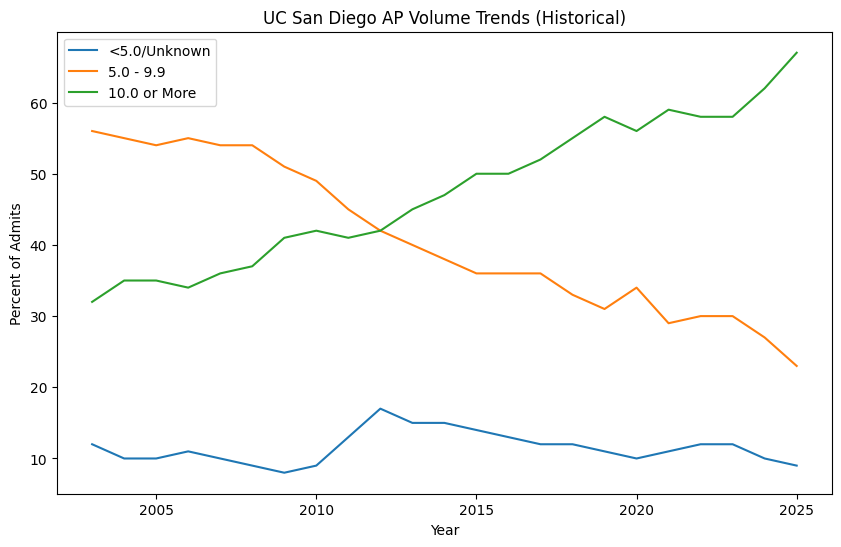

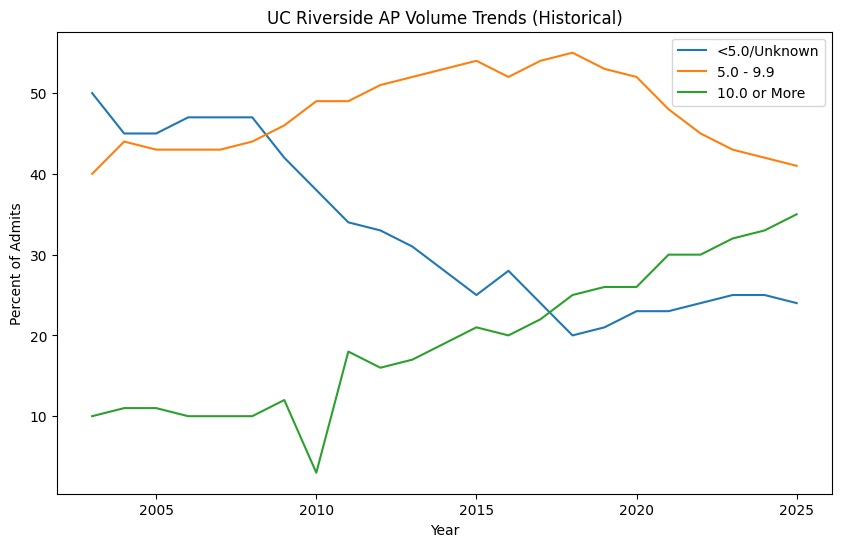

In [48]:
def plot_school_trends(wide, school, bins):
    df_school = wide[wide["school"] == school].sort_values("Year")
    plt.figure(figsize=(10,6))
    for b in bins:
        plt.plot(df_school["Year"], df_school[b], label=b)
    plt.title(f"{school} AP Volume Trends (Historical)")
    plt.xlabel("Year")
    plt.ylabel("Percent of Admits")
    plt.legend()
    plt.show()

plot_school_trends(wide, "UC San Diego", bins)
plot_school_trends(wide, "UC Riverside", bins)

In [49]:
def compare_degrees(df_school, bins, degrees=(1, 2, 3), test_years=5):
    df_school = df_school.sort_values("Year")

    X = df_school[["Year"]].values
    y = df_school[bins].values

    X_train, X_test = X[:-test_years], X[-test_years:]
    y_train, y_test = y[:-test_years], y[-test_years:]

    results = []

    for d in degrees:
        model = Pipeline([
            ("poly", PolynomialFeatures(degree=d, include_bias=False)),
            ("reg", MultiOutputRegressor(Ridge(alpha=1.0)))
        ])

        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, pred)
        results.append((d, mae))

    return pd.DataFrame(results, columns=["Degree", "MAE"]).sort_values("MAE")

ucsd = wide[wide["school"] == "UC San Diego"]
compare_degrees(ucsd, bins)

/Users/alyssagong/.pyenv/versions/3.10.4/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.39965e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/alyssagong/.pyenv/versions/3.10.4/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.39965e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/alyssagong/.pyenv/versions/3.10.4/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.39965e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


,Degree,MAE
0,1,2.242125
1,2,2.276116
2,3,2.589348


In [50]:
def train_eval_forecast(df_school, school_name, bins, degree=1, alpha=1.0, test_years=5, horizon=5):
    # prepare data 
    df_school = df_school.sort_values("Year").copy()
    X = df_school[["Year"]].values
    y = df_school[bins].values

    # split data
    X_train, X_test = X[:-test_years], X[-test_years:]
    y_train, y_test = y[:-test_years], y[-test_years:]

    # model
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("reg", MultiOutputRegressor(Ridge(alpha=alpha)))
    ])

    model.fit(X_train, y_train)

    # evaluation
    pred_test = model.predict(X_test)

    mae_per_bin = {
        bins[i]: mean_absolute_error(y_test[:, i], pred_test[:, i])
        for i in range(len(bins))
    }
    mae_overall = mean_absolute_error(y_test, pred_test)

    # forecast 
    last_year = int(df_school["Year"].max())
    future_years = np.arange(last_year + 1, last_year + horizon + 1).reshape(-1, 1)

    future_pred_raw = model.predict(future_years)

    # point forecast: clip + renormalize
    future_pred = np.maximum(future_pred_raw, 0)
    row_sums = future_pred.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums == 0, 1, row_sums)
    future_pred = 100 * future_pred / row_sums

    # bounds on RAW predictions (then clip + renormalize)
    lower_bounds = future_pred_raw.copy()
    upper_bounds = future_pred_raw.copy()

    for i, bin_name in enumerate(bins):
        error = mae_per_bin[bin_name]
        lower_bounds[:, i] = future_pred_raw[:, i] - error
        upper_bounds[:, i] = future_pred_raw[:, i] + error

    # clip negatives then renormalize bounds to sum to 100
    lower_bounds = np.maximum(lower_bounds, 0)
    upper_bounds = np.maximum(upper_bounds, 0)

    lb_sums = lower_bounds.sum(axis=1, keepdims=True)
    ub_sums = upper_bounds.sum(axis=1, keepdims=True)
    lb_sums = np.where(lb_sums == 0, 1, lb_sums)
    ub_sums = np.where(ub_sums == 0, 1, ub_sums)

    lower_bounds = 100 * lower_bounds / lb_sums
    upper_bounds = 100 * upper_bounds / ub_sums
    
    forecast = pd.DataFrame(future_pred, columns=bins)
    forecast.insert(0, "Year", future_years.flatten())
    forecast.insert(1, "school", school_name)

    for i, bin_name in enumerate(bins):
        forecast[f"{bin_name}_lower"] = lower_bounds[:, i]
        forecast[f"{bin_name}_upper"] = upper_bounds[:, i]

    return model, mae_per_bin, mae_overall, forecast

In [51]:
schools = wide["school"].unique()

all_forecasts = []
all_mae = {}

for school in schools:
    df_school = wide[wide["school"] == school].sort_values("Year")
    
    model, mae_per_bin, mae_overall, forecast = train_eval_forecast(
        df_school, school, bins, degree=1
    )
    
    all_forecasts.append(forecast)
    all_mae[school] = mae_overall

In [52]:
# MAE table
mae_df = pd.DataFrame({"school": list(all_mae.keys()), "MAE": list(all_mae.values())}).sort_values("MAE")

mae_df

,school,MAE
6,UC San Diego,2.242125
3,UC Los Angeles,2.949392
1,UC Davis,3.197216
0,UC Berkeley,3.983263
7,UC Santa Barbara,4.955060
2,UC Irvine,5.449517
8,UC Santa Cruz,6.472083
5,UC Riverside,9.643498
4,UC Merced,9.885997


In [53]:
# forecast table
forecast_all = pd.concat(all_forecasts, ignore_index=True)
forecast_all = forecast_all.sort_values(["school", "Year"]).reset_index(drop=True)

display_df = forecast_all.copy()
for bin_name in bins:
    display_df[bin_name] = (
        display_df[bin_name].round(1).astype(str)
        + " ("
        + display_df[f"{bin_name}_lower"].round(1).astype(str)
        + "–"
        + display_df[f"{bin_name}_upper"].round(1).astype(str)
        + ")"
    )
display_df = display_df[["Year", "school"] + bins]
display_df.head(20)

,Year,school,<5.0/Unknown,5.0 - 9.9,10.0 or More
0,2026,UC Berkeley,6.6 (6.4–6.7),16.7 (12.7–19.9),76.7 (80.9–73.5)
1,2027,UC Berkeley,6.4 (6.3–6.5),15.5 (11.3–18.8),78.1 (82.4–74.6)
2,2028,UC Berkeley,6.3 (6.1–6.4),14.4 (10.0–17.8),79.4 (83.9–75.8)
3,2029,UC Berkeley,6.1 (5.9–6.3),13.2 (8.7–16.7),80.7 (85.4–77.0)
4,2030,UC Berkeley,6.0 (5.8–6.1),12.0 (7.3–15.7),82.0 (86.9–78.2)
5,2026,UC Davis,14.9 (15.0–14.8),36.5 (35.7–37.1),48.6 (49.3–48.1)
6,2027,UC Davis,14.5 (14.6–14.4),35.5 (34.6–36.3),50.0 (50.8–49.3)
7,2028,UC Davis,14.1 (14.2–14.1),34.5 (33.5–35.4),51.4 (52.3–50.6)
8,2029,UC Davis,13.7 (13.7–13.7),33.5 (32.4–34.5),52.7 (53.8–51.8)
9,2030,UC Davis,13.3 (13.3–13.4),32.6 (31.3–33.6),54.1 (55.4–53.1)


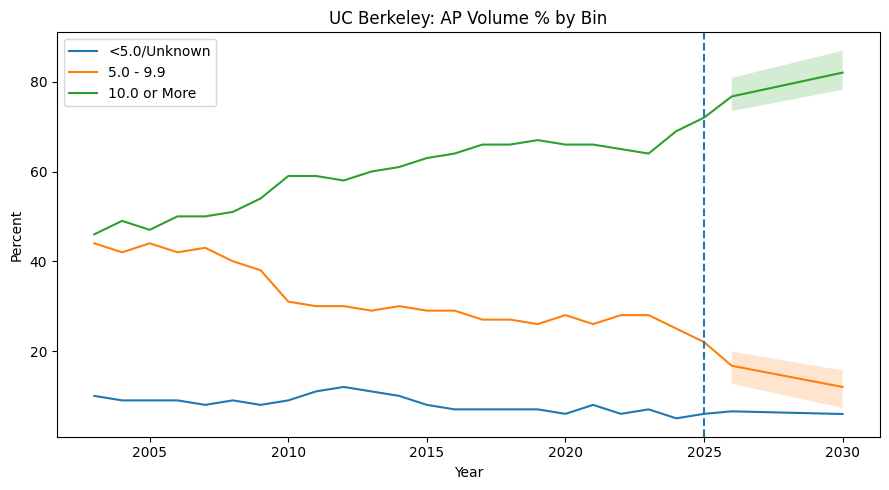

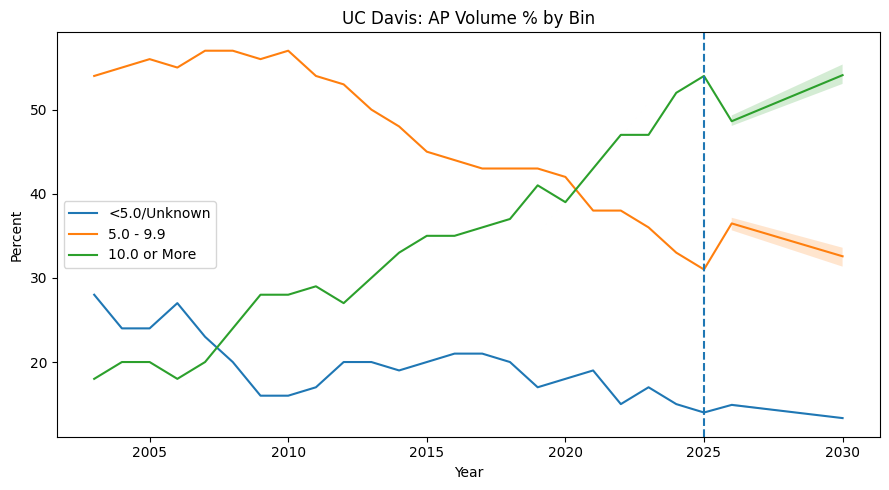

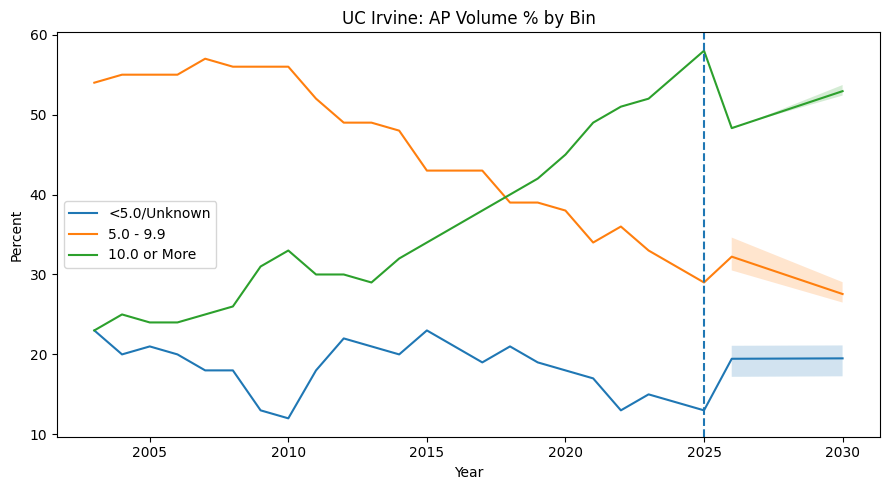

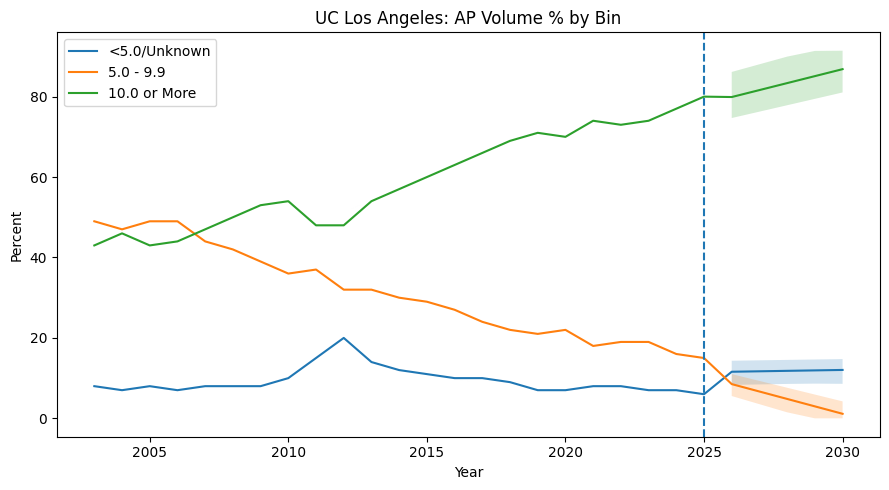

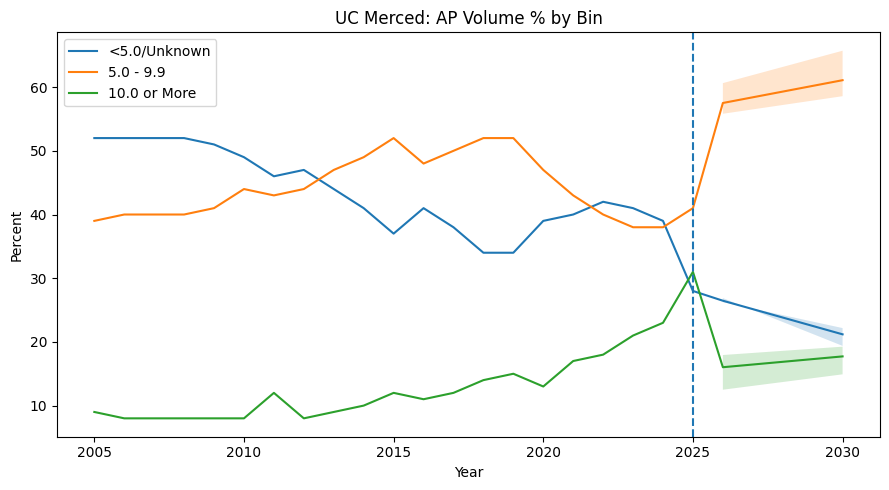

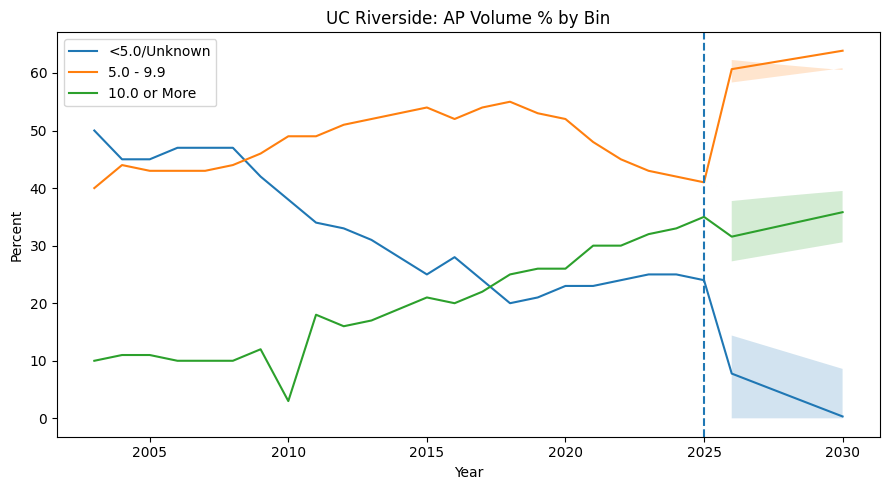

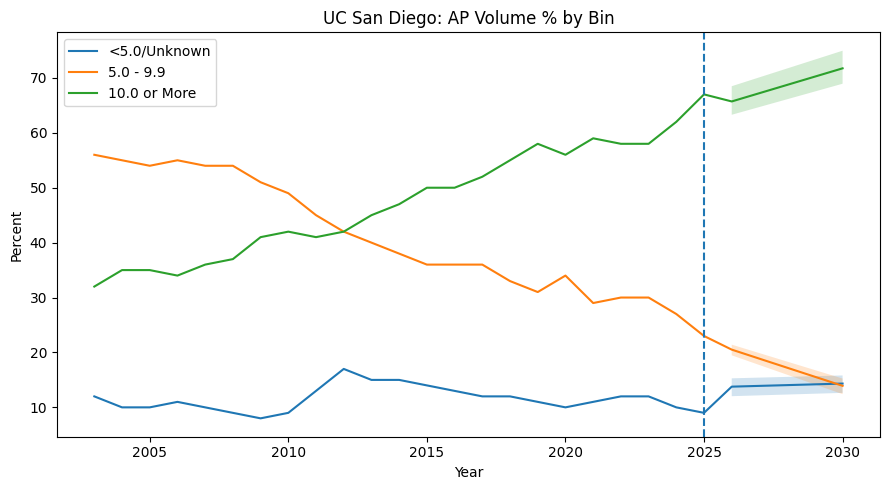

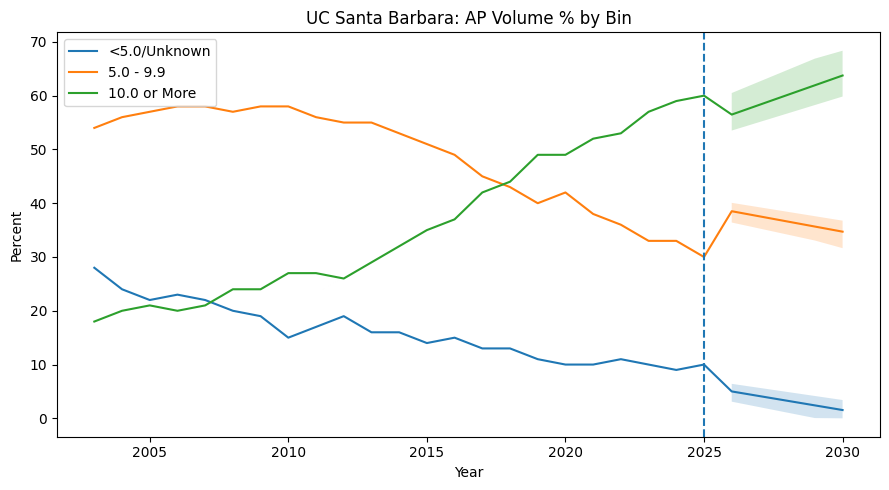

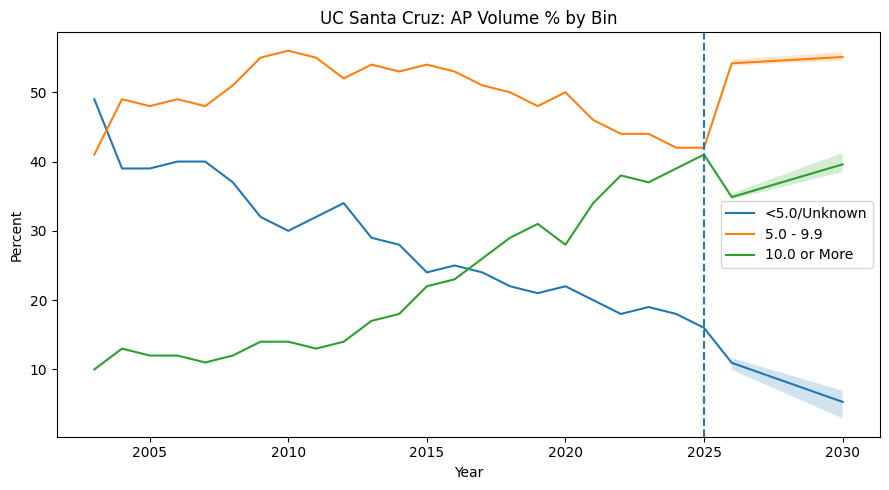

In [55]:
for school in schools:

    # historical
    hist = wide[wide["school"] == school][["Year"] + bins]

    # forecast
    fut = forecast_all[forecast_all["school"] == school]

    # combine for full line
    combo = pd.concat([
        hist,
        fut[["Year"] + bins]
    ]).sort_values("Year")

    plt.figure(figsize=(9,5))

    for b in bins:
        plt.plot(combo["Year"], combo[b], label=b)

        # uncertainty shading for forecast
        plt.fill_between(
            fut["Year"],
            fut[f"{b}_lower"],
            fut[f"{b}_upper"],
            alpha=0.2
        )

    last_actual = hist["Year"].max()
    plt.axvline(last_actual, linestyle="--")

    plt.title(f"{school}: AP Volume % by Bin")
    plt.xlabel("Year")
    plt.ylabel("Percent")
    plt.legend()

    plt.tight_layout()
    plt.show()